In [9]:
pip install numpy


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/332.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/332.0 MB 1.7 MB/s eta 0:03:18
   ---------------------------------------- 1.0/332.0 MB 1.8 MB/s eta 0:03:02
   ---------------------------------------- 1.3/332.0 MB 1.9 MB/s eta 0:02:59
   ---------------------------------------- 1.8/332.0 MB 1.9 MB/s eta 0:02:53
   ---------------------------------------- 2.4/332.0 MB 2.0 MB/s eta 0:02:49
   ---------------------------------------- 2.6/332.0 MB 1.9 MB/s eta 0:02:52
   ---------------------------------------- 2.9/332.0 MB 1.9 MB/s eta 0:02:57
   ---------------------------------------- 3.1/332.0 MB 1.9 MB/s eta 0:02:54
   ---------------------------------------- 3.4/332.0 MB 1.8 MB/s eta 0:03:06
   ---------------------------------------- 3.9/332.0 MB 1.8 MB/s eta 0:03:07


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [13]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 710.1 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/8.1 MB 926.6 kB/s eta 0:00:08
   ----- ---------------------------------- 1.0/8.1 MB 1.0 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.1 MB 1.1 MB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.1 MB 1.0 MB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.1 MB 1.1 MB/s eta 0:00:06
   --------- ------------------------------ 1.8/8.1 MB 1.1 MB/s eta 0:00:06
   --------- ----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [14]:
#Import Libraries
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

#Data Preprocessing

In [17]:
# Set your dataset path
train_dir = r"C:\Users\Rivindu\Desktop\Skin Diseases\Skin_DataSet\train"
test_dir = r"C:\Users\Rivindu\Desktop\Skin Diseases\Skin_DataSet\test"

# Image parameters
IMG_HEIGHT = 224  # Standard size for most pre-trained models
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,      # Normalize pixel values to [0,1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Only rescaling for Testing (no augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical'  # for multi-class classification
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # important for testing
)

Found 1564 images belonging to 4 classes.
Found 268 images belonging to 4 classes.


In [19]:
pip install scipy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/38.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.5 MB ? eta -:--:--
    --------------------------------------- 0.5/38.5 MB 863.2 kB/s eta 0:00:45
    --------------------------------------- 0.8/38.5 MB 947.5 kB/s eta 0:00:40
   - -------------------------------------- 1.0/38.5 MB 985.8 kB/s eta 0:00:39
   - -------------------------------------- 1.3/38.5 MB 1.1 MB/s eta 0:00:34
   - -------------------------------------- 1.8/38.5 MB 1.3 MB/s eta 0:00:29
   -- ------------------------------------- 2.4/38.5 MB 1.4 MB/s eta 0:00:26
   -- ------------------------------------- 2.6/38.5 MB 1.4 MB/s eta 0:00:26
   -- ------------------------------------- 2.9/38.5 MB 1.4 MB/s eta 0:00:25
   --- ------------------------------------ 3.4/38.5 MB 1.5 MB/s eta 0:00:24
   --- ------

Class indices: {'Acne': 0, 'Eczema': 1, 'Elevated mole': 2, 'Warts': 3}
Training samples: 1564
Test samples: 268


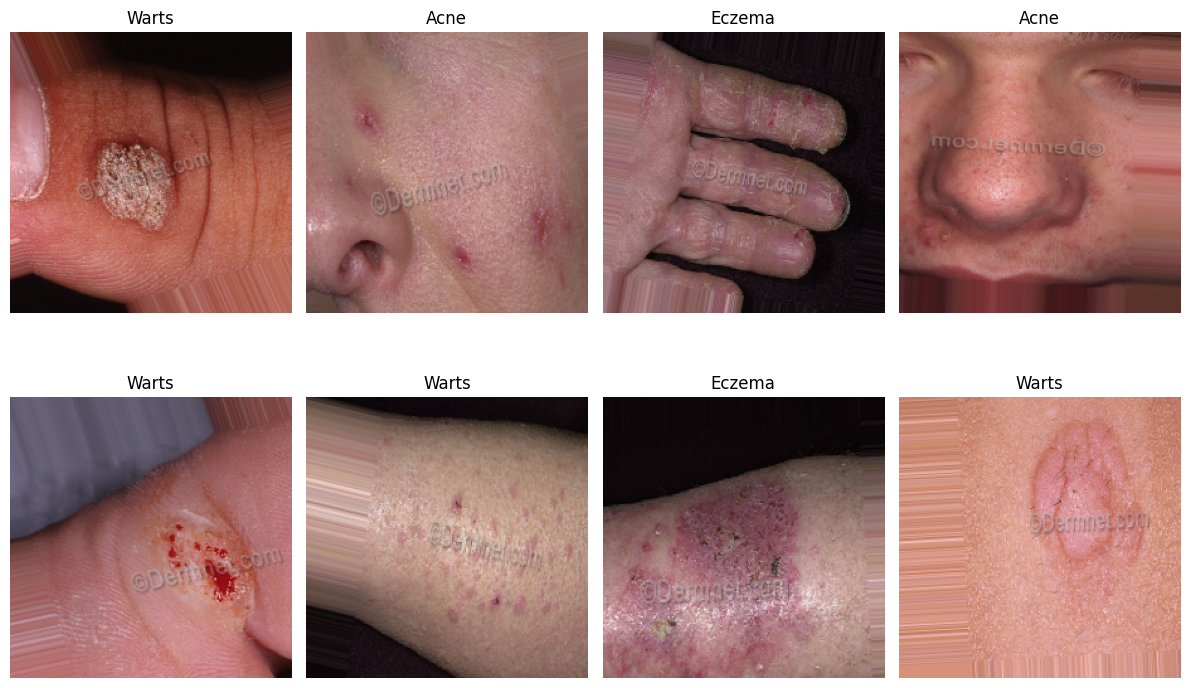

In [20]:
# Check if it's working
print("Class indices:", train_generator.class_indices)
print("Training samples:", train_generator.samples)
print("Test samples:", test_generator.samples)

# Visualize some images to verify
def plot_sample_images(generator):
    images, labels = next(generator)
    class_names = list(generator.class_indices.keys())

    plt.figure(figsize=(12, 8))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_images(train_generator)

#Build and Train CNN Model

In [21]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import datetime

# Load the pre-trained MobileNetV2 model
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the base model (don't train existing layers initially)
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)  # Reduce overfitting
predictions = Dense(4, activation='softmax')(x)  # 4 classes: acne, eczema, mole, warts

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Model summary
model.summary()

# Set up callbacks for better training
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_skin_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=20,
    validation_data=test_generator,
    validation_steps=test_generator.samples // BATCH_SIZE,
    callbacks=[checkpoint, early_stop]
)

# Save the final model
model.save('skin_disease_model.h5')
print("Model training completed and saved!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

...

48/48 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.7245 - loss: 0.6787 - val_accuracy: 0.7148 - val_loss: 0.7332
Epoch 4/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.7500 - loss: 0.6349 - val_accuracy: 0.7148 - val_loss: 0.7334
Epoch 5/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7546 - loss: 0.6030

48/48 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.7617 - loss: 0.5992 - val_accuracy: 0.7188 - val_loss: 0.7226
Epoch 6/20
 1/48 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.8438 - loss: 0.4451

48/48 ━━━━━━━━━━━━━━━━━━━━ 12s 222ms/step - accuracy: 0.8438 - loss: 0.4451 - val_accuracy: 0.7266 - val_loss: 0.7084
Epoch 7/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8021 - loss: 0.5781

48/48 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.7846 - loss: 0.5748 - val_accuracy: 0.7422 - val_loss: 0.6809
Epoch 8/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 170ms/step - accuracy: 0.7812 - loss: 0.6906 - val_accuracy: 0.7383 - val_loss: 0.6828
Epoch 9/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.7755 - loss: 0.5450 - val_accuracy: 0.7383 - val_loss: 0.6747
Epoch 10/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.7500 - loss: 0.5799 - val_accuracy: 0.7383 - val_loss: 0.6699
Epoch 11/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.8022 - loss: 0.5081 - val_accuracy: 0.7227 - val_loss: 0.6740
Epoch 12/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 11s 204ms/step - accuracy: 0.7812 - loss: 0.6165 - val_accuracy: 0.7148 - val_loss: 0.6729
Epoch 13/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.8035 - loss: 0.4720 - val_accuracy: 0.7188 - val_loss: 0.6711
Epoch 14/20
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 168ms/step - accuracy: 0.7188 - loss: 0.6128 - val_accuracy: 0.7227 - val_

Model training completed and saved!


#Evaluate Model

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 971ms/step - accuracy: 0.7201 - loss: 0.6500
Test Accuracy: 72.01%


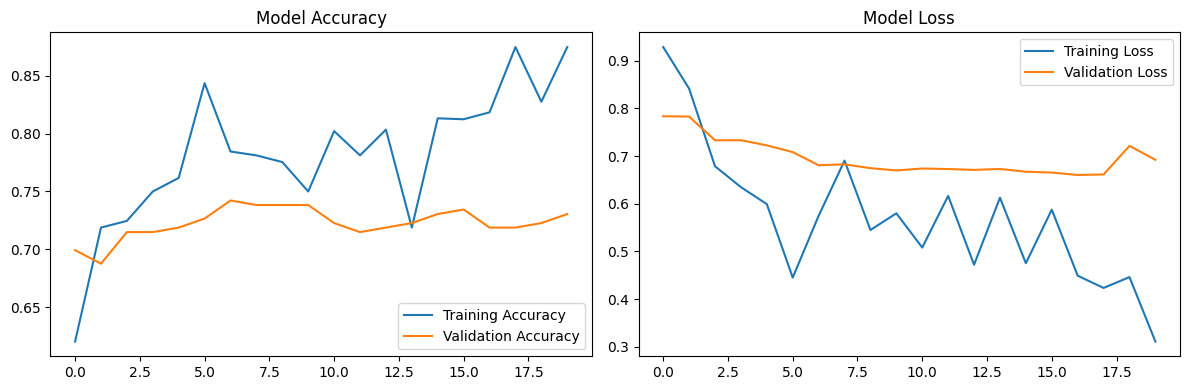

In [22]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.2%}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [23]:
# Save your trained model for future use
model.save('skin_disease_model_v1.h5')
print("Model saved successfully!")

# Also save the class indices for later use
import json
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)

print("Class indices saved.")
print("Disease classes:", class_names)

Model saved successfully!
Class indices saved.
Disease classes: ['Acne', 'Eczema', 'Elevated mole', 'Warts']


#--------------------Prediction Function-------------------------------------------------------

In [25]:
#Create a simple function to test model:
def predict_skin_disease(image_path, model_path='skin_disease_model_v1.h5'):
    # Load model and class indices
    model = tf.keras.models.load_model(model_path)

    with open('class_indices.json', 'r') as f:
        class_indices = json.load(f)

    class_names = list(class_indices.keys())

    # Load and preprocess image
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0  # Normalize

    # Predict
    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    return predicted_class, confidence

# Test your function
# result = predict_skin_disease('path/to/test/image.jpg')
# print(f"Prediction: {result[0]}, Confidence: {result[1]:.2%}")

In [60]:
# Insert and test correct picture
# Test function with one image from your test dataset
try:
    # Replace with the actual path to one of your test images
    test_image_path = r"C:\Users\Rivindu\Desktop\Skin Diseases\Sample image\heroimage0.186835001730238066.jpg"

    result = predict_skin_disease(test_image_path)
    predicted_class, confidence = result

    print(f"🎯 Prediction: {predicted_class}")
    print(f"📊 Confidence: {confidence:.2%}")
    print(f"✅ Test successful!")

except FileNotFoundError:
    print("❌ Image file not found. Please check the path.")
except Exception as e:
    print(f"❌ Error: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
🎯 Prediction: Eczema
📊 Confidence: 89.43%
✅ Test successful!


#Test with Multiple Images from Test Folder

In [29]:
import os
import random

def test_multiple_images(test_folder_path, num_images=5):
    """Test the model with random images from your test folder"""

    # Get all image paths from your test folder
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
    all_images = []

    for disease_folder in os.listdir(test_folder_path):
        disease_path = os.path.join(test_folder_path, disease_folder)
        if os.path.isdir(disease_path):
            for file in os.listdir(disease_path):
                if any(file.lower().endswith(ext) for ext in image_extensions):
                    all_images.append((os.path.join(disease_path, file), disease_folder))

    # Select random images to test
    selected_images = random.sample(all_images, min(num_images, len(all_images)))

    print(f"🧪 Testing {len(selected_images)} images...")
    print("=" * 50)

    correct_predictions = 0

    for image_path, true_class in selected_images:
        try:
            predicted_class, confidence = predict_skin_disease(image_path)
            is_correct = predicted_class.lower() == true_class.lower()

            if is_correct:
                correct_predictions += 1
                status = "✅ CORRECT"
            else:
                status = "❌ WRONG"

            print(f"{status} | True: {true_class:12} | Predicted: {predicted_class:12} | Confidence: {confidence:.2%}")

        except Exception as e:
            print(f"❌ ERROR with {os.path.basename(image_path)}: {e}")

    accuracy = correct_predictions / len(selected_images)
    print("=" * 50)
    print(f"📈 Test Accuracy: {accuracy:.2%} ({correct_predictions}/{len(selected_images)})")

# Usage example:
# test_multiple_images("path/to/your/test/folder", num_images=10)

#Interactive Test with Image Display

In [30]:
import matplotlib.pyplot as plt
from PIL import Image

def test_with_display(image_path):
    """Test and display the image with prediction"""

    # Make prediction
    predicted_class, confidence = predict_skin_disease(image_path)

    # Display the image
    img = Image.open(image_path)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2%}",
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return predicted_class, confidence

# Usage:
# test_with_display("path/to/your/image.jpg")

#Batch Test on Entire Test Set

In [31]:
def evaluate_on_full_testset(test_dir):
    """Evaluate model on entire test dataset"""

    # Recreate your test generator
    test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224),
        batch_size=32,
        class_mode='categorical',
        shuffle=False
    )

    # Load your model
    model = tf.keras.models.load_model('skin_disease_model_v1.h5')

    # Evaluate
    test_loss, test_accuracy = model.evaluate(test_generator)

    print("📊 Full Test Set Evaluation:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.2%}")
    print(f"Number of test samples: {test_generator.samples}")

# Usage:
# evaluate_on_full_testset("path/to/your/test/folder")

In [32]:
# Example path structure - adjust based on your folder structure
test_folder = r"C:\Users\Rivindu\Desktop\Skin Diseases\Skin_DataSet\test"  # Your test folder path

# Test one specific image
test_image = r"C:\Users\Rivindu\Desktop\Skin Diseases\Skin_DataSet\test\Acne\acne-cystic-46.jpg"
test_image2 = r"C:\Users\Rivindu\Desktop\Skin Diseases\Skin_DataSet\test\Elevated mole\atypical-nevi-10.jpg"

# Test multiple images
test_multiple_images(r"C:\Users\Rivindu\Desktop\Skin Diseases\Skin_DataSet\test", num_images=8)

🧪 Testing 8 images...


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
❌ WRONG | True: Eczema       | Predicted: Warts        | Confidence: 69.10%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
✅ CORRECT | True: Acne         | Predicted: Acne         | Confidence: 87.65%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
❌ WRONG | True: Warts        | Predicted: Eczema       | Confidence: 33.99%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
❌ WRONG | True: Elevated mole | Predicted: Acne         | Confidence: 33.92%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
❌ WRONG | True: Warts        | Predicted: Eczema       | Confidence: 78.91%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
✅ CORRECT | True: Eczema       | Predicted: Eczema       | Confidence: 89.85%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
✅ CORRECT | True: Acne         | Predicted: Acne         | Confidence: 87.83%


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
✅ CORRECT | True: Acne         | Predicted: Acne         | Confidence: 97.64%
📈 Test Accuracy: 50.00% (4/8)


In [37]:
# Just test one image to see if everything works
try:
    # Replace with an actual image path from your computer
    result = predict_skin_disease(r"C:\Users\Rivindu\Desktop\Skin Diseases\Skin_DataSet\test\Elevated mole\congenital-nevus-31.jpg")
    print(f"Prediction: {result[0]}, Confidence: {result[1]:.2%}")
except:
    print("Please specify the correct path to your test image")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Acne, Confidence: 88.70%
